In [4]:
import pandas as pd
import numpy as np
customers = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_customers_dataset.csv")
geolocation = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_geolocation_dataset.csv")
order_items = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_order_items_dataset.csv")
payments = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_order_payments_dataset.csv")
reviews = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_order_reviews_dataset.csv")
orders = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_orders_dataset.csv")
products = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_products_dataset.csv")
sellers = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\olist_sellers_dataset.csv")
category_translation = pd.read_csv(r"C:\Users\Shrusti R\Downloads\olist_project\data\product_category_name_translation.csv")

In [5]:
print(customers)

                            customer_id                customer_unique_id  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       customer_zip_code_prefix          customer_city customer_state  
0  

In [6]:
# Give every table a name
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

In [7]:
for name, df in tables.items():
    print(name, ":", df.shape)

customers : (99441, 5)
geolocation : (1000163, 5)
order_items : (112650, 7)
payments : (103886, 5)
reviews : (100000, 7)
orders : (99441, 8)
products : (32951, 9)
sellers : (3095, 4)
category_translation : (71, 2)


In [9]:
# Data Dictionary
for name, df in tables.items():
    print("\n==============================")
    print(name.upper())
    print("==============================")
    print(df.columns.tolist())
#This gives you the columns in every table.


CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

GEOLOCATION
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

ORDER_ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'prod

CUSTOMERS

customer_id
→ ID associated with the customer record

customer_unique_id
→ identifies the actual customer across orders

customer_city
→ customer's city

customer_state
→ customer's state

In [10]:
#Find missing values across ALL tables
for name, df in tables.items():
    print("\n", name.upper())
    print(df.isnull().sum().sort_values(ascending=False))


 CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 GEOLOCATION
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

 ORDER_ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 PAYMENTS
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 REVIEWS
review_comment_title       88285
review_comment_message     58247
review_id                      0
order_id                       0
review_score                   0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

 ORDERS
order_delivere

In [11]:
#Percentage of missing data
for name, df in tables.items():
    missing = df.isnull().sum()
    percentage = (missing / len(df)) * 100
    
    result = pd.DataFrame({
        "missing_count": missing,
        "missing_percentage": percentage
    })
    
    print("\n==============================")
    print(name.upper())
    print("==============================")
    print(result[result["missing_count"] > 0].sort_values(
        "missing_percentage", ascending=False
    ))


CUSTOMERS
Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []

GEOLOCATION
Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []

ORDER_ITEMS
Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []

PAYMENTS
Empty DataFrame
Columns: [missing_count, missing_percentage]
Index: []

REVIEWS
                        missing_count  missing_percentage
review_comment_title            88285              88.285
review_comment_message          58247              58.247

ORDERS
                               missing_count  missing_percentage
order_delivered_customer_date           2965            2.981668
order_delivered_carrier_date            1783            1.793023
order_approved_at                        160            0.160899

PRODUCTS
                            missing_count  missing_percentage
product_category_name                 610            1.851234
product_name_lenght                   610            1.851234
product_description_le

In [12]:
#Check duplicate rows
for name, df in tables.items():
    print(name, "→ duplicate rows:", df.duplicated().sum())

customers → duplicate rows: 0
geolocation → duplicate rows: 261831
order_items → duplicate rows: 0
payments → duplicate rows: 0
reviews → duplicate rows: 0
orders → duplicate rows: 0
products → duplicate rows: 0
sellers → duplicate rows: 0
category_translation → duplicate rows: 0


In [14]:
#Find unique values
# from Customer states
customers["customer_state"].nunique()

27

In [15]:
#count
customers["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [16]:
# unique count of first 10 entry
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

visualization 📊
Let's see customer distribution by state.

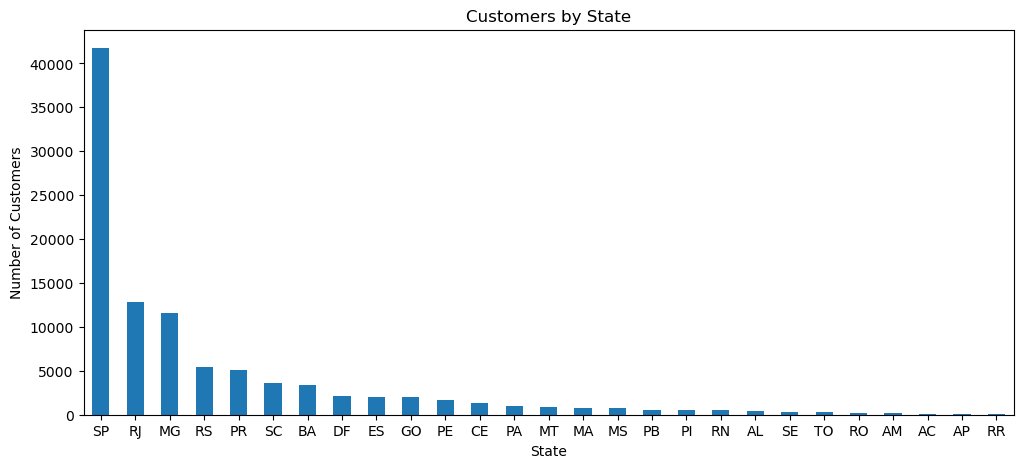

In [17]:
import matplotlib.pyplot as plt

state_counts = customers["customer_state"].value_counts()

state_counts.plot(kind="bar", figsize=(12, 5))

plt.title("Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [18]:
#Understand the ORDER table
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [21]:
#Convert dates properly
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [22]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [23]:
#Find the time period of the data
print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [24]:
#Find order status distribution
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [25]:
#In percentage 
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [26]:
#How many orders are delivered?
orders["order_status"].value_counts().get("delivered", 0)

np.int64(96478)

In [30]:
#Calculate delivery time
delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

In [31]:
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

In [32]:
delivered_orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

In [33]:
#Was the order delivered late?
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

In [34]:
delivered_orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

In [35]:
late_orders = delivered_orders[
    delivered_orders["delivery_delay_days"] > 0
]

In [36]:
len(late_orders)

7827

In [37]:
late_percentage = (
    len(late_orders) / len(delivered_orders)
) * 100

print("Late delivery percentage:", late_percentage)

Late delivery percentage: 8.112898544715783


Understand the customer relationship
Remember:
   customer_id
   customer_unique_id

In [38]:
print("Customer records:", customers["customer_id"].nunique())

print(
    "Unique actual customers:",
    customers["customer_unique_id"].nunique()
)

Customer records: 99441
Unique actual customers: 96096


In [39]:
customer_orders = customers.groupby(
    "customer_unique_id"
)["customer_id"].count()

In [40]:
customer_orders.value_counts().sort_index()

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [41]:
#Understand the money
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [42]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [43]:
#Total product value
total_product_value = order_items["price"].sum()

print("Total product value:", total_product_value)

Total product value: 13591643.7


In [44]:
#Total freight
total_freight = order_items["freight_value"].sum()

print("Total freight:", total_freight)

Total freight: 2251909.54


In [45]:
#Average product price
print("Average product price:", order_items["price"].mean())

Average product price: 120.65373901464713


Create your first business KPI

Let's calculate Average Order Value (AOV).

Conceptually:

AOV = Total Revenue / Number of Orders

In [46]:
total_revenue = order_items["price"].sum()
total_orders = order_items["order_id"].nunique()

aov = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", aov)

Total Revenue: 13591643.7
Total Orders: 98666
Average Order Value: 137.75407637889444


Understand the complete data model
CUSTOMERS
    |
    | customer_id
    ↓
ORDERS
    |
    ├──────────────→ PAYMENTS
    |
    ├──────────────→ REVIEWS
    |
    ↓
ORDER_ITEMS
    |       |
    |       └────────→ SELLERS
    |
    └──────────────→ PRODUCTS
                         |
                         ↓
                  CATEGORY TRANSLATION

AND:
CUSTOMERS
    |
    └── customer_zip_code_prefix
              ↓
        GEOLOCATION
This structure is going to become very important when we start SQL and Power BI.        

# Olist Data Understanding Report

## Dataset Overview

Number of tables:

Total customers:

Total orders:

Total products:

Total sellers:

Total order items:

## Data Quality

Tables with missing values:

Tables with duplicates:

## Time Period

First order:

Last order:

## Customer Insights

Number of unique customers:

## Order Insights

Number of orders:

Most common order status:

## Delivery

Average delivery time:

Late delivery percentage:

## Sales

Total product value:

Average Order Value: